In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "irrigation_prediction.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


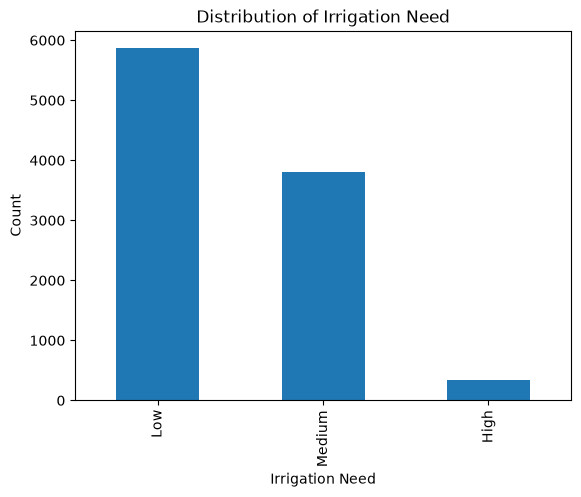

In [3]:
df["Irrigation_Need"].value_counts().plot(kind="bar")

plt.title("Distribution of Irrigation Need")
plt.xlabel("Irrigation Need")
plt.ylabel("Count")

plt.show()

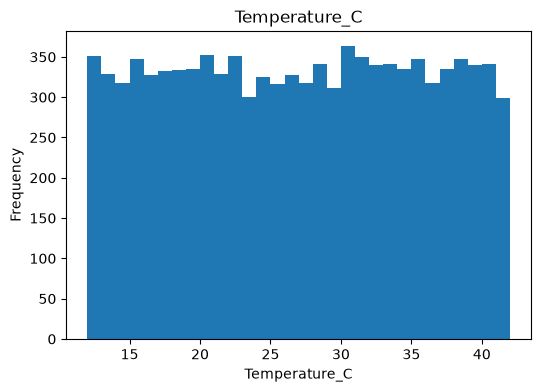

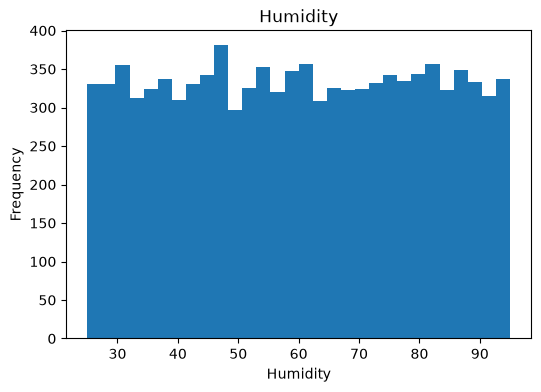

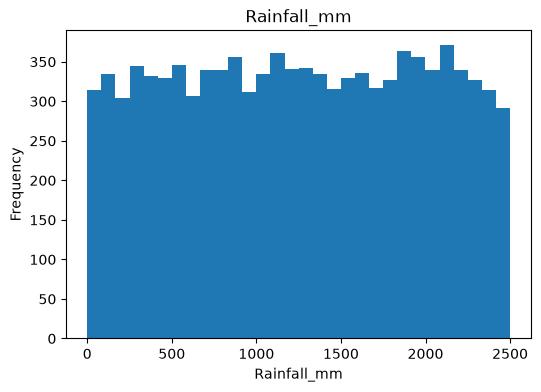

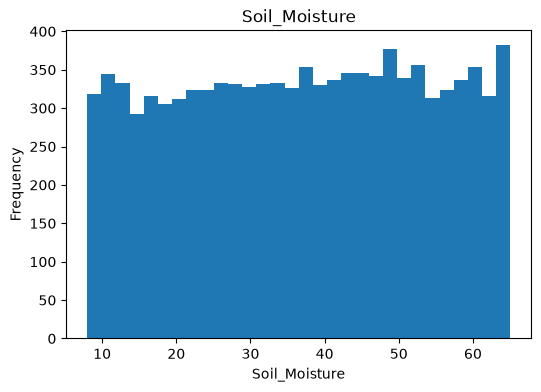

In [5]:
features = [
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Soil_Moisture",
]
for feature in features:

    plt.figure(figsize=(6,4))

    plt.hist(df[feature], bins=30)

    plt.title(feature)

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.show()

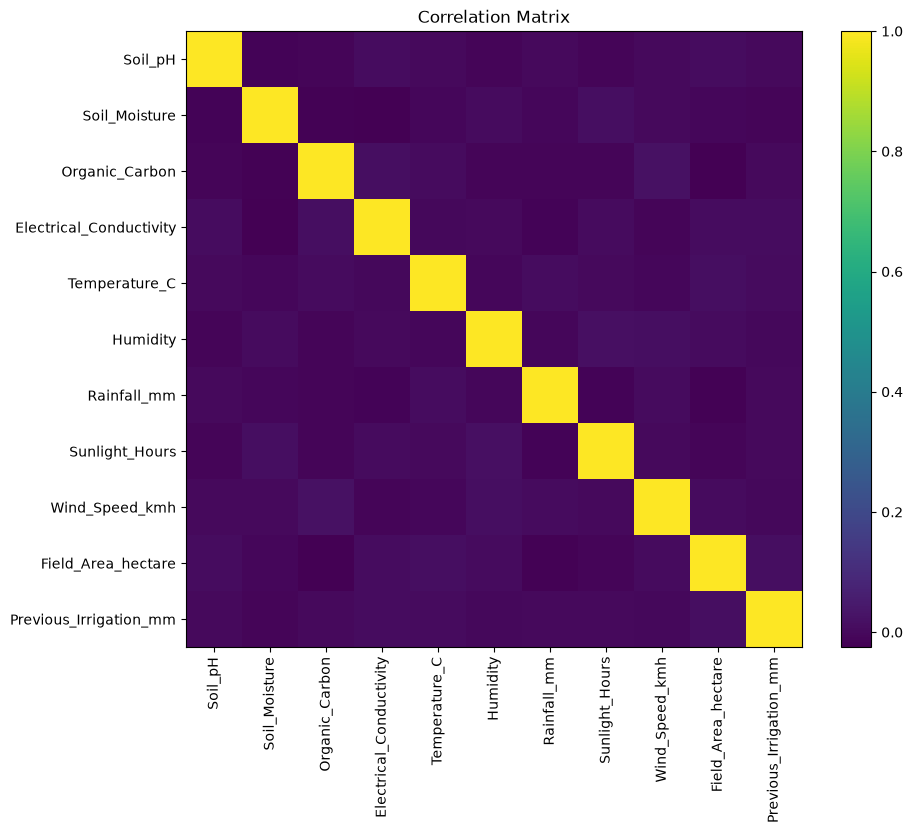

In [6]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

In [7]:
pd.crosstab(
    df["Crop_Type"],
    df["Irrigation_Need"]
)

Irrigation_Need,High,Low,Medium
Crop_Type,,,
Cotton,55,928,612
Maize,68,976,650
Potato,51,954,658
Rice,44,1030,637
Sugarcane,65,987,626
Wheat,53,989,617


In [8]:
pd.crosstab(
    df["Soil_Type"],
    df["Irrigation_Need"]
)

Irrigation_Need,High,Low,Medium
Soil_Type,,,
Clay,85,1442,950
Loamy,74,1488,924
Sandy,96,1479,961
Silt,81,1455,965


In [9]:
pd.crosstab(
    df["Season"],
    df["Irrigation_Need"]
)

Irrigation_Need,High,Low,Medium
Season,,,
Kharif,113,1947,1302
Rabi,115,2016,1252
Zaid,108,1901,1246


In [10]:
pd.crosstab(
    df["Irrigation_Type"],
    df["Irrigation_Need"]
)

Irrigation_Need,High,Low,Medium
Irrigation_Type,,,
Canal,91,1396,980
Drip,69,1469,957
Rainfed,83,1512,916
Sprinkler,93,1487,947


C:\Users\nudas\AppData\Local\Temp\ipykernel_28540\2757223689.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


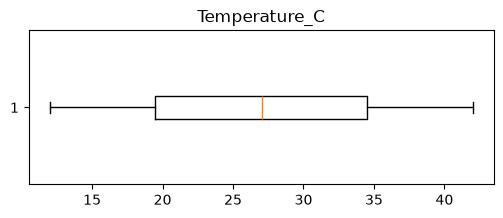

C:\Users\nudas\AppData\Local\Temp\ipykernel_28540\2757223689.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


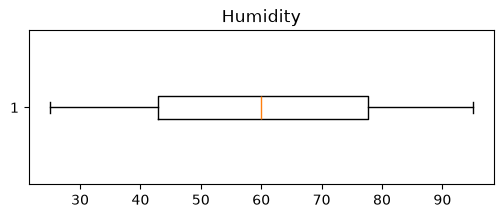

C:\Users\nudas\AppData\Local\Temp\ipykernel_28540\2757223689.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


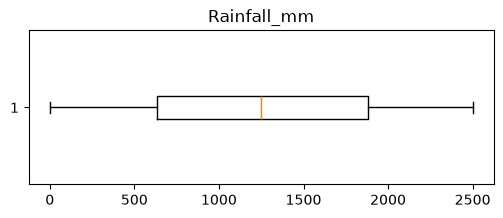

C:\Users\nudas\AppData\Local\Temp\ipykernel_28540\2757223689.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=False)


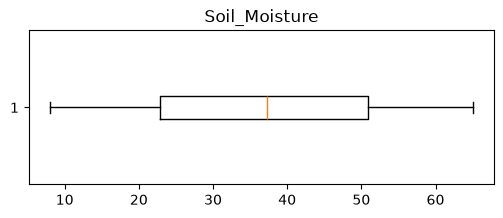

In [11]:
features = [
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Soil_Moisture"
]

for feature in features:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[feature], vert=False)

    plt.title(feature)

    plt.show()

In [12]:
plt.savefig(
    PROJECT_ROOT /
    "reports" /
    "figures" /
    "target_distribution.png"
)

<Figure size 640x480 with 0 Axes>

# EDA Summary

## Key Findings

- Dataset appears balanced / imbalanced.
- Temperature distribution is ...
- Rainfall distribution is ...
- Soil moisture shows ...
- No significant outliers were observed / Some outliers exist.
- Categorical features appear informative.
- Dataset is suitable for multiclass classification.

## Next Step

Build a preprocessing pipeline and compare classification models.